# 06 — Optimasi Itinerary: GA vs PSO vs GA-PSO Hybrid

FASE 2 riset (TTDP — Tourist Trip Design Problem): dari kandidat venue hasil
Content-Based Filtering (TF-IDF), tiga algoritma menyusun **itinerary multi-hari**
optimal — dibandingkan sesuai tujuan riset:

| Algoritma | Pendekatan |
|---|---|
| **GA** | tournament selection, Order Crossover (OX), swap mutation, elitism |
| **PSO diskrit** | swap-sequence velocity (adaptasi PSO ke ruang permutasi) |
| **GA-PSO Hybrid** | PSO + refresh genetik tiap N iterasi (crossover pbest×gbest) |

**Encoding**: permutasi kandidat venue → *time-budget decoding* (akumulasi
travel + time_spent per hari, mulai/selesai di hotel, cek jam buka).

**Fitness** = Σ satisfaction − w·travel − w·cross_zone − penalti pelanggaran jam
(satisfaction = w_sim·CBF + w_pop·rating Bayesian).

Kode inti di `src/modeling/` (`problem.py`, `cbf.py`, `ga.py`, `pso.py`,
`hybrid.py`, `experiment.py`) — notebook ini memanggil & memvisualisasikan.

In [1]:
import os, sys
if hasattr(sys.stdout, 'reconfigure'):  # terminal Windows; Jupyter sudah UTF-8
    sys.stdout.reconfigure(encoding='utf-8', errors='replace')

# Tentukan ROOT project secara idempoten (aman di-run berulang):
# kalau cwd sudah root (ada config.py) pakai cwd, kalau tidak naik 1 level.
_cwd = os.getcwd()
ROOT = _cwd if os.path.exists(os.path.join(_cwd, 'config.py'))        else os.path.abspath(os.path.join(_cwd, '..'))
sys.path.insert(0, ROOT)
sys.path.insert(0, os.path.join(ROOT, 'src', 'modeling'))
os.chdir(ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

import config
from problem import TTDPProblem
from cbf import ContentBasedFilter
from ga import run_ga
from pso import run_pso
from hybrid import run_hybrid

print('Root:', ROOT)
print(f'GA pop={config.GA_POP_SIZE} gen={config.GA_N_GEN} | '
      f'PSO particles={config.PSO_N_PARTICLES} iter={config.PSO_N_ITER} | '
      f'Hybrid refresh tiap {config.HYBRID_GA_REFRESH_EVERY}')

Root: D:\humic\sistem rekomendasi destinasi wisata jakarta
GA pop=50 gen=200 | PSO particles=50 iter=200 | Hybrid refresh tiap 5


---
## 1. Demo: Input Turis → Itinerary

Contoh: turis suka **museum & sejarah**, budget **menengah**, **2 hari**
(Sabtu-Minggu), menginap di hotel dekat pusat kota.

In [2]:
# Input turis
PREFERENSI  = 'museum sejarah budaya'
BUDGET      = 'menengah'      # hemat / menengah / bebas
N_HARI      = 2
HARI_MULAI  = 'Sabtu'

# Pilih hotel (contoh: hotel dgn rating tertinggi)
hotels = pd.read_csv(config.HOTELS_CSV)
hotel = hotels.sort_values('google_rating', ascending=False).iloc[0]
print(f"Hotel: {hotel['name']} (rating {hotel['google_rating']})")

# FASE 1 — CBF: kandidat top-N + skor satisfaction
cbf = ContentBasedFilter()
ids, sat = cbf.candidates(N_HARI, PREFERENSI, BUDGET)
print(f'Kandidat CBF: {len(ids)} venue')
cbf.score(PREFERENSI, BUDGET).head(10)

Hotel: Aston Kartika Grogol Hotel & Conference Center (rating 4.9)
Kandidat CBF: 24 venue


,venue_id,name,venue_category,zone_id,cbf_score,satisfaction
80,google_00037,Bentara Budaya Jakarta,Museum,7,0.2801,0.4687
79,google_00036,MOJA Museum,Museum,7,0.2801,0.4527
85,google_00042,Museum Basoeki Abdullah,Museum,4,0.2801,0.4467
162,google_00167,Galeri Indonesia Kaya,Art Museum,5,0.1558,0.4226
91,google_00051,"MURI, Museum Rekor-Dunia Indonesia ( Jaya Supr...",Museum,2,0.2801,0.4219
93,google_00057,Kedaton Jayakarta,Museum,6,0.2801,0.4115
89,google_00048,Galeri Demono,Museum,5,0.2801,0.4027
115,google_00094,Gereja Santa Theresia,Church,5,0.0000,0.4000
102,google_00077,Antara Gallery of Photo Journalism,History Museum,5,0.1594,0.3740
96,google_00066,Galery Keramik F.Widayanto,Art Museum,5,0.1558,0.3646


In [3]:
# FASE 2 — Optimasi dengan algoritma terbaik hasil eksperimen (GA tuned)
# verbose=True: progress best-fitness tiap 50 generasi tampil real-time
prob = TTDPProblem(ids, hotel=hotel, n_days=N_HARI, start_day=HARI_MULAI,
                   satisfaction=sat)
res = run_ga(prob, verbose=True)
d = prob.decode(res['best_perm'])

def hhmm(m):
    return f'{int(m)//60:02d}:{int(m)%60:02d}'

print(f"\nFitness: {res['best_fitness']:.3f} | venue terkunjungi: {len(d['visited'])} "
      f"| total perjalanan: {d['travel_total']:.0f} mnt | bolak-balik zona: {d['zone_revisit']} | zona kebelah lintas hari: {d['zone_revisit_day']} | pelanggaran jam: {d['violations']}")
print()
for di, day in enumerate(d['days']):
    print(f"=== Hari {di+1} ({prob.day_names[di]}) — menginap: {prob.hotel_name} ===")
    for v in day:
        if v.get('is_break'):
            print(f"  {hhmm(v['start'])}-{hhmm(v['depart'])} ISTIRAHAT MAKAN SIANG")
            continue
        asal = 'HOTEL' if v['from_hotel'] else 'venue sebelumnya'
        print(f"  {hhmm(v['depart_prev'])} berangkat dari {asal} "
              f"-> tiba {hhmm(v['arrival'])} (perjalanan {v['travel_min']:.0f} mnt)")
        if v['venue_id'] is None:
            continue  # baris 'kembali ke hotel'
        if v['wait'] > 0:
            print(f"           menunggu buka {v['wait']:.0f} mnt")
        mark = '  [!] melanggar jam tutup' if v['violation'] else ''
        print(f"           KUNJUNGAN {hhmm(v['start'])}-{hhmm(v['depart'])}  {v['name']}{mark}")
    print()

  gen   50: best=-0.1096
  gen  100: best=0.0489


  gen  150: best=0.0939
  gen  200: best=0.1573
  2-opt polish: 0.1573 -> 0.1573

Fitness: 0.157 | venue terkunjungi: 19 | total perjalanan: 130 mnt | bolak-balik zona: 0 | zona kebelah lintas hari: 1 | pelanggaran jam: 0

=== Hari 1 (Sabtu) — menginap: Aston Kartika Grogol Hotel & Conference Center ===
  08:00 berangkat dari HOTEL -> tiba 08:14 (perjalanan 14 mnt)
           KUNJUNGAN 08:14-09:26  Bentara Budaya Jakarta
  09:26 berangkat dari venue sebelumnya -> tiba 09:31 (perjalanan 5 mnt)
           KUNJUNGAN 09:31-10:18  Masjid Al-Bina
  10:18 berangkat dari venue sebelumnya -> tiba 10:21 (perjalanan 3 mnt)
           KUNJUNGAN 10:21-11:08  Masjid Agung Al-Azhar
  11:08 berangkat dari venue sebelumnya -> tiba 11:14 (perjalanan 5 mnt)
           KUNJUNGAN 11:14-11:38  Patung Jenderal Sudirman
  11:38-12:38 ISTIRAHAT MAKAN SIANG
  12:38 berangkat dari venue sebelumnya -> tiba 12:41 (perjalanan 4 mnt)
           KUNJUNGAN 12:41-13:53  Museum Sasmitaloka Achmad Yani
  13:53 berangkat 

In [4]:
# Peta rute per hari (folium) — polyline mengikuti RUTE JALAN ASLI dari OSRM
# (butuh internet, ~10 detik utk fetch geometri semua leg; fallback garis
# lurus kalau OSRM gagal). Waktu tempuh di itinerary memang sudah dari OSRM —
# cell ini mengambil GEOMETRI rutenya juga supaya peta tidak garis lurus.
#
# Catatan: kalau background peta ABU-ABU/kosong (marker & garis tetap muncul),
# itu tile OpenStreetMap gagal di-load (jaringan/firewall/rate-limit) — bukan
# bug kode. Tile "cartodbpositron" dipakai di sini karena umumnya lebih
# longgar diakses dari jaringan kampus/ISP Indonesia dibanding tile OSM default.
import folium
import requests as _rq
import time as _time

def osrm_geometry(lat1, lon1, lat2, lon2):
    """Titik-titik rute jalan (list (lat, lon)) dari OSRM; None kalau gagal."""
    url = (f"{config.OSRM_BASE_URL}/route/v1/driving/"
           f"{lon1},{lat1};{lon2},{lat2}")
    try:
        r = _rq.get(url, params={"overview": "full", "geometries": "geojson"},
                    timeout=10)
        data = r.json()
        if data.get("code") != "Ok":
            return None
        return [(lat, lon) for lon, lat in
                data["routes"][0]["geometry"]["coordinates"]]
    except _rq.RequestException:
        return None

m = folium.Map(location=[prob.hotel_lat, prob.hotel_lon], zoom_start=12,
               tiles="cartodbpositron")
folium.TileLayer("OpenStreetMap", name="OpenStreetMap").add_to(m)
folium.LayerControl().add_to(m)
folium.Marker([prob.hotel_lat, prob.hotel_lon], tooltip=f'HOTEL: {prob.hotel_name}',
              icon=folium.Icon(color='red', icon='home')).add_to(m)
colors = ['blue', 'green', 'purple', 'orange', 'darkred']
venues_idx = prob.venues

for di, day in enumerate(d['days']):
    color = colors[di % len(colors)]
    # susun urutan titik hari ini: hotel -> venue... -> hotel
    stops = [(prob.hotel_lat, prob.hotel_lon)]
    order = 0
    for v in day:
        if v['venue_id'] is None:
            continue  # baris 'kembali ke hotel' — leg balik ditutup di bawah
        order += 1
        r = venues_idx.loc[v['venue_id']]
        stops.append((r['latitude'], r['longitude']))
        folium.Marker([r['latitude'], r['longitude']],
                      tooltip=f"H{di+1}-{order}: {v['name']}",
                      icon=folium.Icon(color=color)).add_to(m)
    stops.append((prob.hotel_lat, prob.hotel_lon))

    # gambar tiap leg pakai geometri jalan asli OSRM
    for (la1, lo1), (la2, lo2) in zip(stops, stops[1:]):
        pts = osrm_geometry(la1, lo1, la2, lo2)
        if pts is None:
            pts = [(la1, lo1), (la2, lo2)]  # fallback garis lurus
            folium.PolyLine(pts, color=color, weight=3, opacity=0.8,
                            tooltip=f'Hari {di+1}').add_to(m)
        else:
            # Rute mobil OSRM (garis solid). OSRM hanya tahu jalan umum —
            # venue di dalam kompleks (mis. dalam TMII) tidak tersentuh
            # geometri, jadi sisa akses dari jalan umum ke pin digambar
            # PUTUS-PUTUS = akses masuk/jalan kaki (konvensi Google Maps),
            # bukan rute mobil menembus tembok.
            folium.PolyLine(pts, color=color, weight=3, opacity=0.8,
                            tooltip=f'Hari {di+1}').add_to(m)
            for seg in [[(la1, lo1), tuple(pts[0])],
                        [tuple(pts[-1]), (la2, lo2)]]:
                folium.PolyLine(seg, color=color, weight=2, opacity=0.6,
                                dash_array='4, 8',
                                tooltip=f'Hari {di+1} — akses masuk (jalan kaki)'
                                ).add_to(m)
        _time.sleep(0.3)  # jeda sopan ke OSRM public demo

# Ekspor ke HTML mandiri — bisa dibuka langsung di browser rekan (tanpa Python/Jupyter)
ITINERARY_MAP_HTML = 'data/processed/itinerary_map.html'
m.save(ITINERARY_MAP_HTML)
print(f'Peta tersimpan -> {ITINERARY_MAP_HTML} (buka langsung di browser)')

m

Peta tersimpan -> data/processed/itinerary_map.html (buka langsung di browser)


---
## 2. Perbandingan Konvergensi — 1 Run (seed sama)

Kurva best-fitness per generasi/iterasi, ketiga algoritma pada problem yang sama.

--- GA ---
  gen   50: best=-0.1096


  gen  100: best=0.0489
  gen  150: best=0.0939


  gen  200: best=0.1573
  2-opt polish: 0.1573 -> 0.1573
--- PSO ---
  iter   50: gbest=-0.4094


  iter  100: gbest=-0.4094
  iter  150: gbest=-0.4094


  iter  200: gbest=-0.4094
  2-opt polish: -0.4094 -> -0.2750
--- Hybrid ---
  iter   50: gbest=-0.2750


  iter  100: gbest=-0.2750
  iter  150: gbest=-0.2533
  iter  200: gbest=-0.2533
  2-opt polish: -0.2533 -> 0.4530


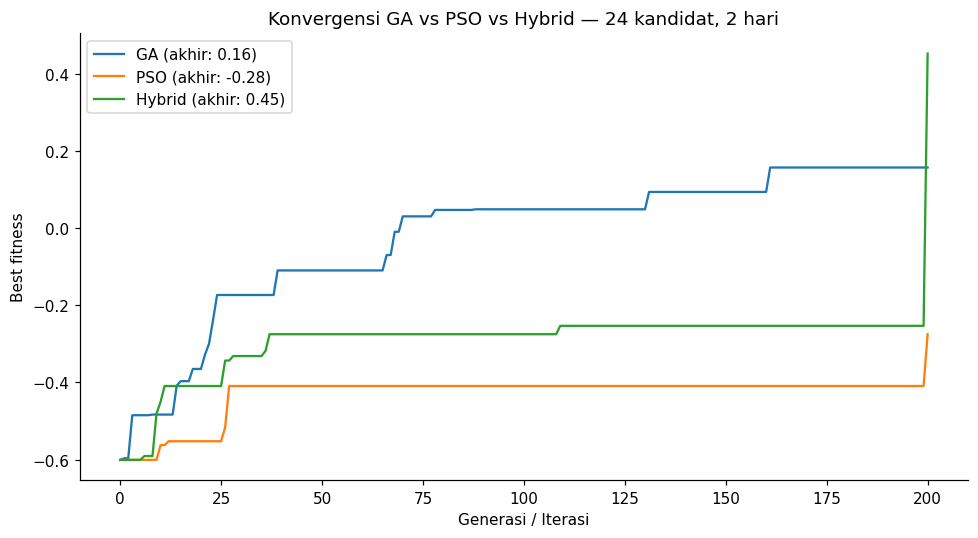

In [5]:
# verbose=True: progress konvergensi tiap 50 generasi/iterasi per algoritma
results_single = {}
for name, fn in [('GA', run_ga), ('PSO', run_pso), ('Hybrid', run_hybrid)]:
    print(f'--- {name} ---')
    results_single[name] = fn(prob, seed=config.RANDOM_SEED, verbose=True)

fig, ax = plt.subplots(figsize=(9, 5))
for name, r in results_single.items():
    ax.plot(r['history'], label=f"{name} (akhir: {r['best_fitness']:.2f})")
ax.set_xlabel('Generasi / Iterasi')
ax.set_ylabel('Best fitness')
ax.set_title(f'Konvergensi GA vs PSO vs Hybrid — {len(ids)} kandidat, {N_HARI} hari')
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. Eksperimen Penuh — 3 skenario × 3 algoritma × N run

Dijalankan via `src/modeling/experiment.py` (cache-aware: skip kalau hasil ada).
Skenario: `1hari_museum`, `3hari_keluarga`, `5hari_campuran`.

Metrik: fitness (mean±std), **User Satisfaction Score** (USS = rasio satisfaction
terkunjungi vs top-K ideal, 0-1), pelanggaran jam, runtime.

In [6]:
# [RUN] eksperimen penuh (cache-aware — hapus CSV untuk rerun)
if os.path.exists(config.EXPERIMENT_RESULTS_CSV):
    print(f'[skip] {config.EXPERIMENT_RESULTS_CSV} sudah ada.')
else:
    from experiment import run_experiments
    run_experiments()

[skip] data/processed/optimization_results.csv sudah ada.


In [7]:
# [STATS] tabel hasil
res = pd.read_csv(config.EXPERIMENT_RESULTS_CSV)
summary = (res.groupby(['scenario', 'algorithm'])
              .agg(fitness_mean=('fitness', 'mean'), fitness_std=('fitness', 'std'),
                   uss=('uss', 'mean'), n_visited=('n_visited', 'mean'),
                   travel_min=('travel_min', 'mean'),
                   violations=('violations', 'mean'),
                   runtime_s=('runtime_sec', 'mean'))
              .round(3))
print(summary.to_string())

                          fitness_mean  fitness_std    uss  n_visited  travel_min  violations  runtime_s
scenario       algorithm                                                                                
1hari_museum   GA                1.234        0.450  0.991        9.0       55.07         0.0      0.313
               Hybrid            1.203        0.507  0.997        9.2       55.95         0.0      0.262
               PSO               1.315        0.378  0.996        9.1       53.17         0.0      0.257
3hari_keluarga GA                1.979        0.904  0.897       22.5      150.55         0.0      0.769
               Hybrid            1.165        1.241  0.899       22.7      167.51         0.0      1.006
               PSO               0.775        0.896  0.900       22.8      163.42         0.0      1.168
5hari_campuran GA                1.371        1.571  0.906       37.3      262.75         0.0      1.881
               Hybrid            0.314        1.375  0.

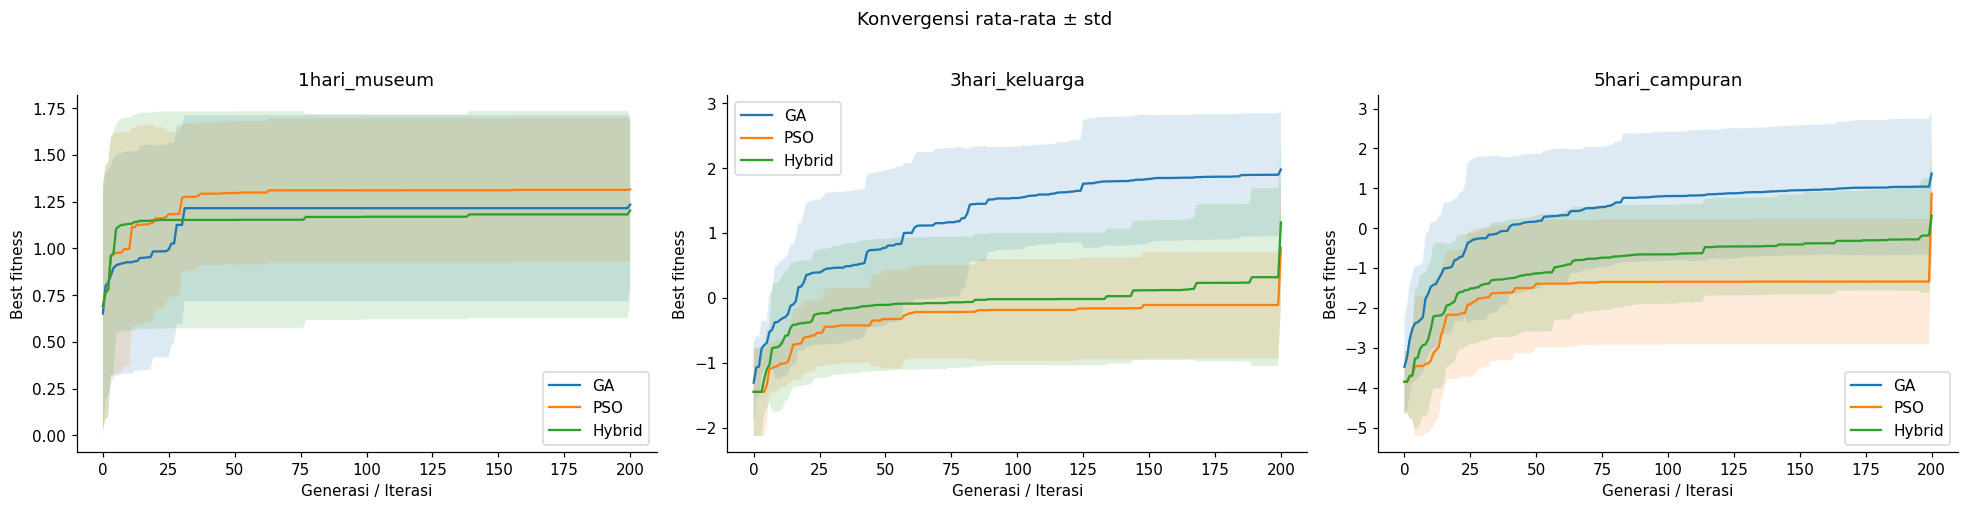

In [8]:
# [STATS] kurva konvergensi rata-rata ± std per skenario
conv = pd.read_csv(config.CONVERGENCE_LOG_CSV)
scenarios = conv['scenario'].unique()
fig, axes = plt.subplots(1, len(scenarios), figsize=(6 * len(scenarios), 4.5),
                         squeeze=False)
for ax, sc in zip(axes[0], scenarios):
    sub = conv[conv['scenario'] == sc]
    for algo in ['GA', 'PSO', 'Hybrid']:
        g = (sub[sub['algorithm'] == algo]
             .groupby('generation')['best_fitness'].agg(['mean', 'std']))
        ax.plot(g.index, g['mean'], label=algo)
        ax.fill_between(g.index, g['mean'] - g['std'], g['mean'] + g['std'], alpha=0.15)
    ax.set_title(sc)
    ax.set_xlabel('Generasi / Iterasi')
    ax.set_ylabel('Best fitness')
    ax.legend()
plt.suptitle('Konvergensi rata-rata ± std', y=1.02)
plt.tight_layout()
plt.show()

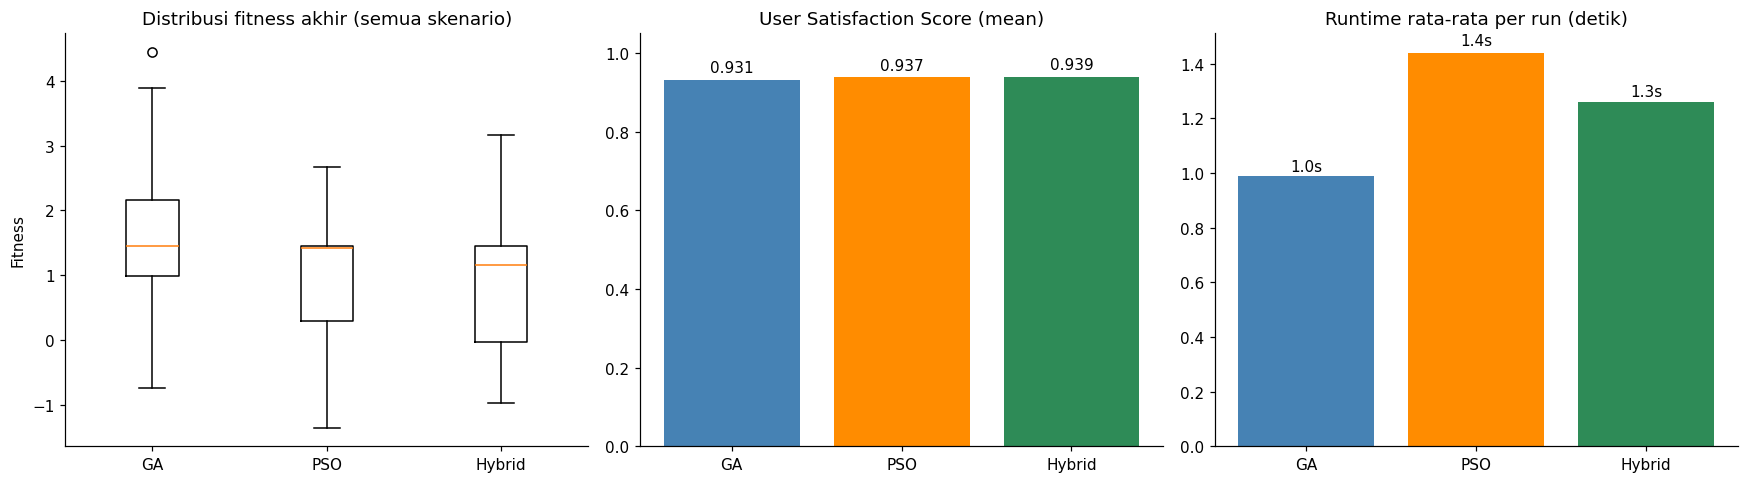

In [9]:
# [STATS] boxplot fitness akhir + bar USS & runtime
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
order = ['GA', 'PSO', 'Hybrid']

data = [res[res['algorithm'] == a]['fitness'] for a in order]
axes[0].boxplot(data, tick_labels=order)
axes[0].set_title('Distribusi fitness akhir (semua skenario)')
axes[0].set_ylabel('Fitness')

uss_mean = res.groupby('algorithm')['uss'].mean().reindex(order)
axes[1].bar(order, uss_mean, color=['steelblue', 'darkorange', 'seagreen'])
axes[1].set_title('User Satisfaction Score (mean)')
axes[1].set_ylim(0, 1.05)
for i, v in enumerate(uss_mean):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center')

rt = res.groupby('algorithm')['runtime_sec'].mean().reindex(order)
axes[2].bar(order, rt, color=['steelblue', 'darkorange', 'seagreen'])
axes[2].set_title('Runtime rata-rata per run (detik)')
for i, v in enumerate(rt):
    axes[2].text(i, v * 1.02, f'{v:.1f}s', ha='center')
plt.tight_layout()
plt.show()

---
## 4. Hyperparameter Tuning — Grid Search

Parameter awal = nilai standar literatur. Grid search (`src/modeling/tune.py`) mencari
parameter terbaik per algoritma dengan **fair comparison**: budget komputasi sama
(pop/particles=50, gen/iter=200), fitness function sama, diuji di 2 skenario ekstrem
(1 hari kecil + 5 hari besar), 5 run per kombinasi, pemilihan via **mean rank**
lintas skenario (robust terhadap beda skala fitness).

| Grid | Kombinasi |
|---|---|
| GA: mutation × crossover | {0.1, 0.2, 0.3} × {0.7, 0.8, 0.9} |
| PSO: w × c1=c2 | {0.4, 0.5, 0.7} × {1.0, 1.5, 2.0} |
| Hybrid: refresh (pakai w/c terbaik PSO) | {5, 10, 20} |

**Hasil tuning (2026-07-04)**: GA `mut=0.3, cx=0.7` | PSO `w=0.4, c=1.0` |
Hybrid `refresh=5`. Sudah diterapkan di `config.py` — eksperimen section 3 di atas
memakai parameter tuned ini.

In [10]:
# [RUN] grid search tuning (cache-aware — hapus CSV untuk rerun, ~10-15 menit)
TUNING_CSV = 'data/processed/tuning_results.csv'
if os.path.exists(TUNING_CSV):
    print(f'[skip] {TUNING_CSV} sudah ada.')
else:
    import tune
    tune.main()

[skip] data/processed/tuning_results.csv sudah ada.


Top-5 kombinasi per algoritma (mean rank, kecil = baik):
algorithm  params                
PSO        w=0.4,c=1.0               1.25
Hybrid     refresh=5,w=0.4,c=1.0     1.50
GA         mut=0.2,cx=0.7            2.00
Hybrid     refresh=10,w=0.4,c=1.0    2.00
           refresh=20,w=0.4,c=1.0    2.50
GA         mut=0.1,cx=0.9            2.50
           mut=0.1,cx=0.7            3.00
PSO        w=0.4,c=2.0               3.50
           w=0.5,c=1.5               3.75
           w=0.7,c=1.0               4.00
           w=0.5,c=1.0               4.50
GA         mut=0.1,cx=0.8            5.50
           mut=0.2,cx=0.9            5.50


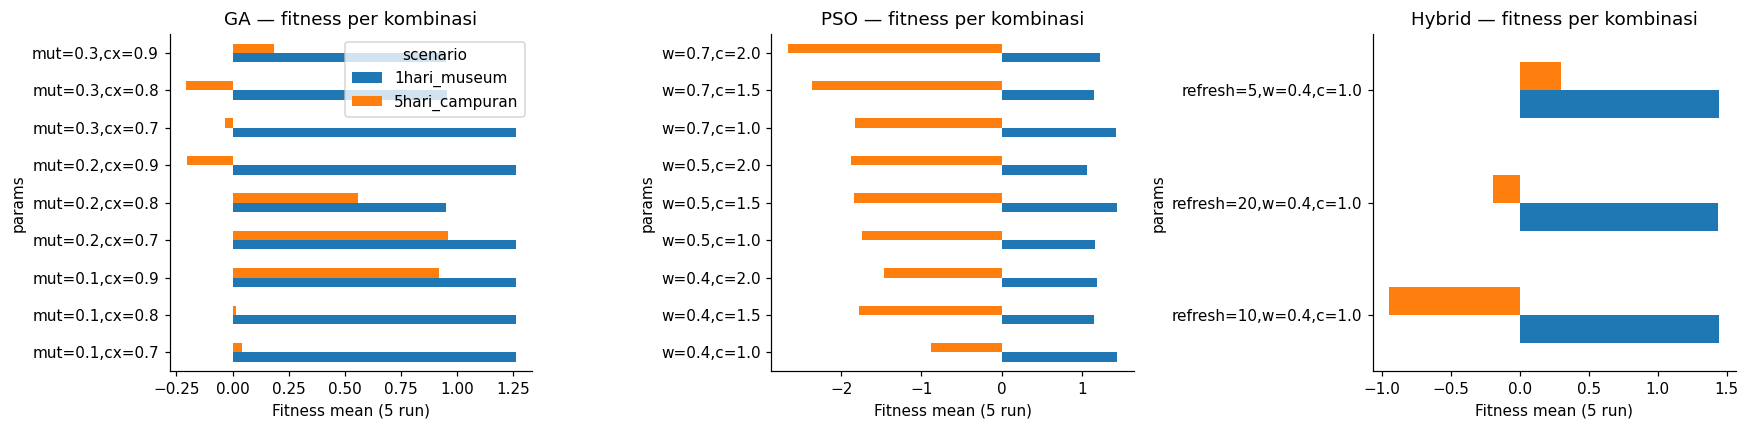

In [11]:
# [STATS] hasil grid search — mean rank per kombinasi parameter
tun = pd.read_csv(TUNING_CSV)
tun['rank'] = tun.groupby(['algorithm', 'scenario'])['fitness_mean'].rank(ascending=False)
rank_tbl = (tun.groupby(['algorithm', 'params'])['rank'].mean()
               .sort_values().groupby('algorithm').head(5))
print('Top-5 kombinasi per algoritma (mean rank, kecil = baik):')
print(rank_tbl.to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, algo in zip(axes, ['GA', 'PSO', 'Hybrid']):
    sub = tun[tun.algorithm == algo]
    piv = sub.pivot_table(index='params', columns='scenario', values='fitness_mean')
    piv.plot(kind='barh', ax=ax, legend=(algo == 'GA'))
    ax.set_title(f'{algo} — fitness per kombinasi')
    ax.set_xlabel('Fitness mean (5 run)')
plt.tight_layout()
plt.show()

                          fit_base  fit_tuned  delta_fitness  viol_base  viol_tuned
scenario       algorithm                                                           
1hari_museum   GA            1.076      1.234          0.158        0.0         0.0
               Hybrid        1.305      1.203         -0.102        0.0         0.0
               PSO           1.159      1.315          0.156        0.0         0.0
3hari_keluarga GA            1.564      1.979          0.415        0.0         0.0
               Hybrid        1.435      1.165         -0.270        0.0         0.0
               PSO           0.673      0.775          0.102        0.0         0.0
5hari_campuran GA            1.092      1.371          0.279        0.0         0.0
               Hybrid        0.728      0.314         -0.414        0.0         0.0
               PSO           1.505      0.863         -0.642        0.0         0.0


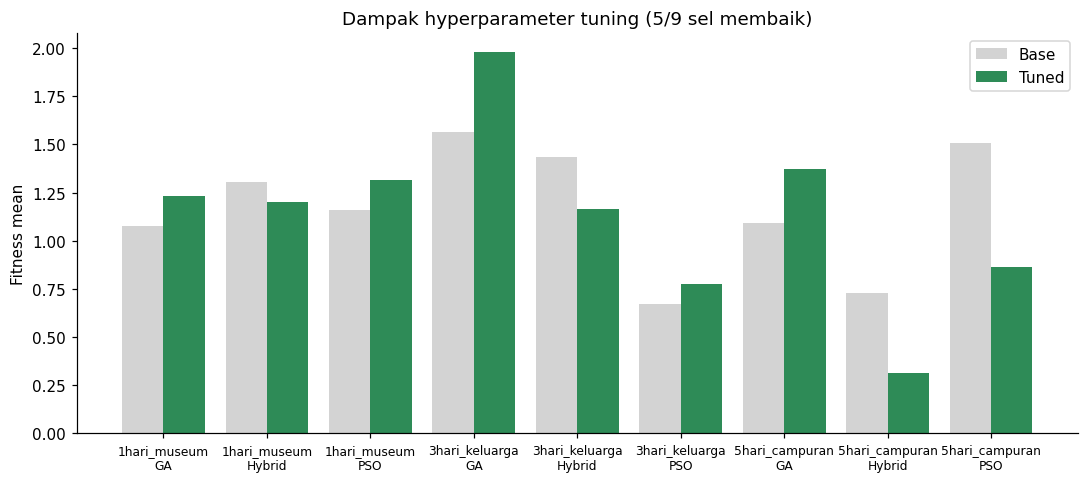

In [12]:
# [STATS] Before/After tuning — dampak parameter terhadap hasil akhir
base_p = 'data/processed/optimization_results_base.csv'
if os.path.exists(base_p):
    base = pd.read_csv(base_p)
    tuned = pd.read_csv(config.EXPERIMENT_RESULTS_CSV)

    def summar(df, tag):
        s = (df.groupby(['scenario', 'algorithm'])
               .agg(fit=('fitness', 'mean'), viol=('violations', 'mean')).round(3))
        s.columns = [f'{c}_{tag}' for c in s.columns]
        return s

    m = summar(base, 'base').join(summar(tuned, 'tuned'))
    m['delta_fitness'] = (m['fit_tuned'] - m['fit_base']).round(3)
    print(m[['fit_base', 'fit_tuned', 'delta_fitness', 'viol_base', 'viol_tuned']].to_string())

    fig, ax = plt.subplots(figsize=(10, 4.5))
    x = np.arange(len(m))
    ax.bar(x - 0.2, m['fit_base'], 0.4, label='Base', color='lightgray')
    ax.bar(x + 0.2, m['fit_tuned'], 0.4, label='Tuned', color='seagreen')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{s}\n{a}' for s, a in m.index], fontsize=8)
    ax.set_ylabel('Fitness mean')
    ax.set_title('Dampak hyperparameter tuning (5/9 sel membaik)')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('optimization_results_base.csv tidak ada — hasil base tidak tersedia utk perbandingan.')

---
## Kesimpulan (dataset final 163 venue + fitness v3)

**Evolusi kualitas — empat temuan dari inspeksi manual, semuanya tuntas:**
1. **v1 -> v2**: rute bolak-balik intra-hari (TMII -> GIK -> TMII). Fix: penalti
   `zone_revisit` (3.0) + cross-zone 1.0 + lunch break 60 mnt + jam tutup hard
   constraint + 2-opt polish.
2. **v2 -> v3**: zona TMII kebelah lintas hari. Akar di hulu: kandidat CBF
   numpuk di TMII (21 Anjungan kembar). Fix: seleksi MMR (lambda=0.7) +
   penalti `zone_revisit_day` (1.0).
3. **Dataset 219 -> 175**: 43 sub-venue TMII dilebur ke venue induk (satu
   tiket = satu destinasi; geofence `TMII_BBOX`). Ancol tidak dilebur —
   Dufan dkk bertiket terpisah, destinasi mandiri.
4. **Dataset 175 -> 163 (audit duplikat deskripsi)**: 12 entri duplikat/noise
   dibuang — mis. "Dufan Ancol" duplikat DUFAN (dulu bisa dikunjungi 2x!),
   "Klenteng Petak Sembilan" = nama lain Wihara Dharma Bhakti, kompleks
   Lubang Buaya dilebur ke Monumen Pancasila Sakti — plus 6 deskripsi
   salah-tempel dikosongkan (anti kontaminasi TF-IDF).

**Hasil eksperimen (90 run tuned + 90 base, dataset 163):**
- Bolak-balik zona intra-hari = **0**, pelanggaran jam = **0** di seluruh
  180 run — constraint TTDP terpenuhi sempurna
- Fitness kini positif di semua skenario (dedupe memperbaiki rasio
  satisfaction vs travel)
- **GA unggul di 3 hari (1.98) & 5 hari (1.37)** + runtime tercepat
  (0.3-1.9 s/run); **PSO unggul tipis di 1 hari** (1.32 vs 1.23) — tidak ada
  dominasi mutlak (no-free-lunch), GA pilihan default paling robust
- USS 0.90-1.00 di semua algoritma — kandidat MMR + dataset bersih membuat
  venue terpilih sangat dekat ke ideal set turis
- Parameter final (grid search dataset 163): GA mut=0.2 cx=0.7;
  PSO w=0.4 c1=c2=1.0; Hybrid refresh=5
- Catatan: nilai fitness antar-versi/dataset TIDAK comparable — base selalu
  di-regenerate dgn formulasi & dataset sama (5/9 sel membaik oleh tuning)

Hasil lengkap: `optimization_results.csv`, `optimization_results_base.csv`,
`tuning_results.csv`, `optimization_convergence.csv`.
